### Assignment-1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"../Day_8/preprocessed_earthquake_data.csv")

Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

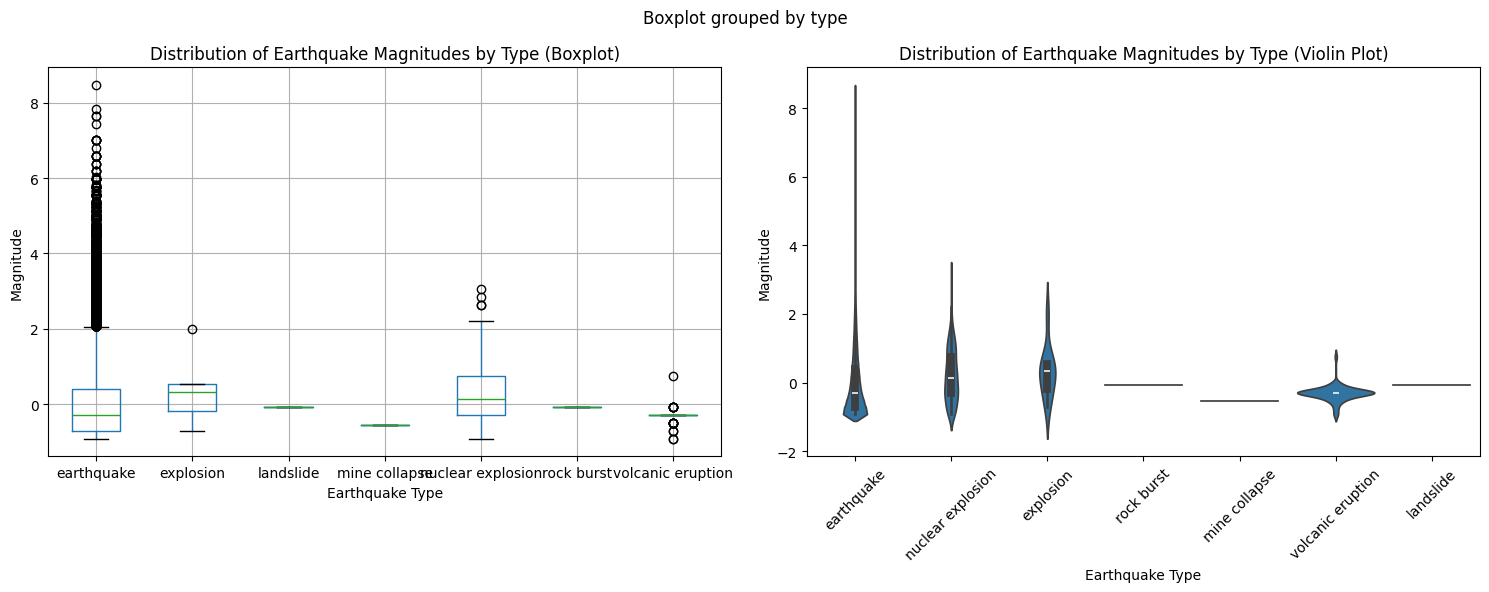

In [3]:


# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
df.boxplot(column='mag', by='type', ax=ax1)
ax1.set_title('Distribution of Earthquake Magnitudes by Type (Boxplot)')
ax1.set_xlabel('Earthquake Type')
ax1.set_ylabel('Magnitude')

# Violin plot
sns.violinplot(x='type', y='mag', data=df, ax=ax2)
ax2.set_title('Distribution of Earthquake Magnitudes by Type (Violin Plot)')
ax2.set_xlabel('Earthquake Type')
ax2.set_ylabel('Magnitude')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

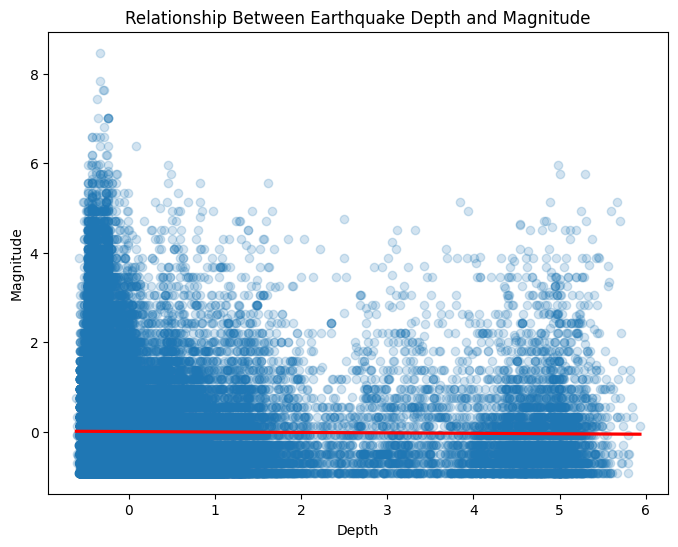

In [4]:
plt.figure(figsize=(8,6))
sns.regplot(x='depth', y='mag', data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Relationship Between Earthquake Depth and Magnitude')
plt.xlabel('Depth')
plt.ylabel('Magnitude')
plt.show()

Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

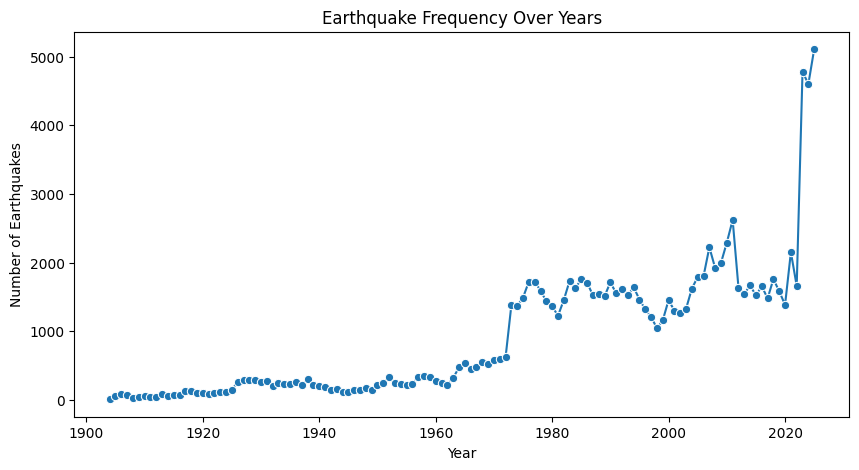

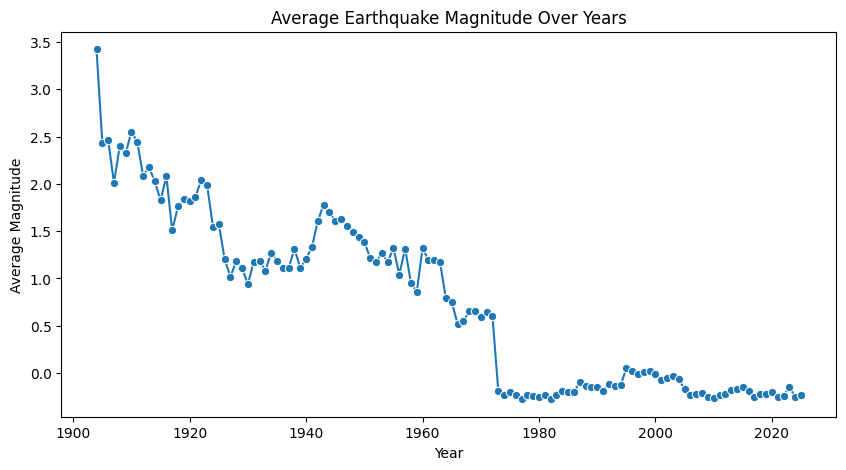

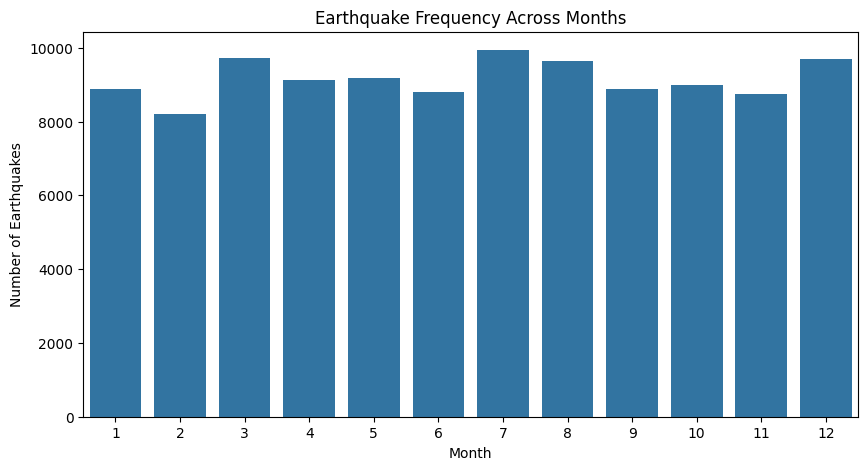

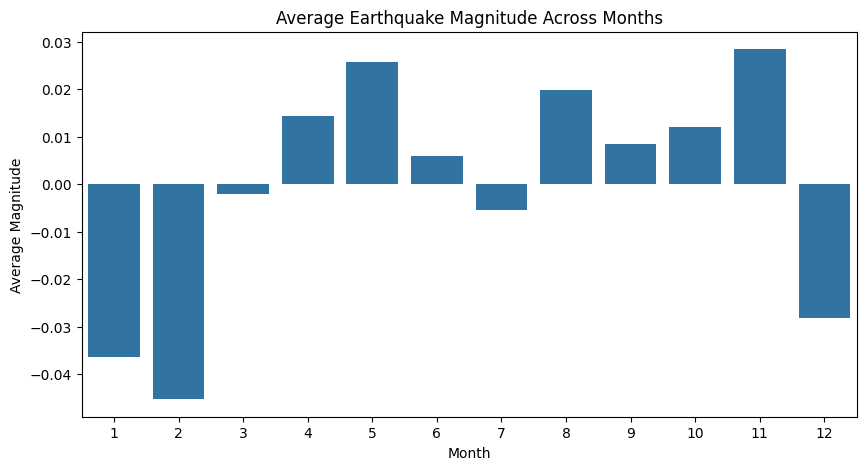

In [5]:
# Earthquake count per year
yearly_counts = df.groupby('Year').size().reset_index(name='Count')

# Average magnitude per year
yearly_mag = df.groupby('Year')['mag'].mean().reset_index(name='Avg_Magnitude')

# Yearly trends 
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='Count', data=yearly_counts, marker='o')
plt.title('Earthquake Frequency Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='Avg_Magnitude', data=yearly_mag, marker='o')
plt.title('Average Earthquake Magnitude Over Years')
plt.xlabel('Year')
plt.ylabel('Average Magnitude')
plt.show()

# Monthly trends
monthly_counts = df.groupby('Month').size().reset_index(name='Count')
monthly_mag = df.groupby('Month')['mag'].mean().reset_index(name='Avg_Magnitude')

plt.figure(figsize=(10,5))
sns.barplot(x='Month', y='Count', data=monthly_counts)
plt.title('Earthquake Frequency Across Months')
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='Month', y='Avg_Magnitude', data=monthly_mag)
plt.title('Average Earthquake Magnitude Across Months')
plt.xlabel('Month')
plt.ylabel('Average Magnitude')
plt.show()


Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

In [6]:
import plotly.express as px
df['mag'] = (df['mag'] - df['mag'].min()) / (df['mag'].max() - df['mag'].min())

fig = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color='mag',
    size='mag',
    opacity=0.6,
    size_max=10,
    projection='natural earth',
    color_continuous_scale='Viridis',
    hover_name='type',
    title='Global Earthquake Locations (Transparent Markers)'
)
fig.show()